In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt
from matplotlib_venn import venn3

import statsmodels.api as sm

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


# Read data

In [2]:
#df = pd.read_parquet('/Users/julianeoliveira/Downloads/aesop_2025_11_10_mun_withMEM.parquet')
#df = pd.read_parquet('/Users/julianeoliveira/Downloads/aesop_2025_11_10_mun_withMEM.parquet')
#df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_31_03_2026_with_MEM_all_models.parquet')
df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/resultado_ensemble31_03_2026_mlp_xgb.parquet')
dta = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/cities_valid_for_MEM_26_03_2026.parquet')

# Select cities for the manuscript analysis (valid MEM)
lst = list(set(df.co_ibge.unique()) - set(dta.co_ibge.unique()))
df = df[~df.co_ibge.isin(lst)]

df =  df[(df.year_week >= '2022-42') &(df.year_week <= '2025-32')]

data = df.copy()

In [6]:
# Base variables
lst_models = [
    'sinal_ears_atend', 'sinal_evi_ivas',
    'EWS_ISF', 'EWS_LOF', 'EWS_OCSVM',
    'EWS_COPOD', 'EWS_Rt'
]

lags = [1, 2, 3]

# Create lagged features
lagged_cols = []

for var in lst_models:
    for lag in lags:
        col_name = f"{var}_lag_{lag}"
        
        lagged_cols.append(col_name)

# Final feature list
all_features = lst_models + lagged_cols

# Study an ensamble definition

In [12]:
code = 355030
set_muni = data[data.co_ibge == code].sort_values(['year_week'])

# --- create lagged features ---
for var in lst_models:
    for lag in [1, 2, 3]:
        set_muni[f"{var}_lag_{lag}"] = set_muni[var].shift(lag).fillna(0).astype(int)

In [13]:
set_muni.columns

Index(['co_ibge', 'epiweek', 'year', 'year_week', 'week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend', 'sinal_evi_ivas',
       'EWS_ISF', 'EWS_LOF', 'EWS_OCSVM', 'EWS_COPOD', 'EWS_Rt',
       'prob_ensemble_xgb', 'signal_ensemble_xgb50', 'prob_ensemble_mlp',
       'signal_ensemble_mlp50', 'sinal_ears_atend_lag_1',
       'sinal_ears_atend_lag_2', 'sinal_ears_atend_lag_3',
       'sinal_evi_ivas_lag_1', 'sinal_evi_ivas_lag_2', 'sinal_evi_ivas_lag_3',
       'EWS_ISF_lag_1', 'EWS_ISF_lag_2', 'EWS_ISF_lag_3', 'EWS_LOF_lag_1',
       'EWS_LOF_lag_2', 'EWS_LOF_lag_3', 'EWS_OCSVM_lag_1', 'EWS_OCSVM_lag_2',
       'EWS_OCSVM_lag_3', 'EWS_COPOD_lag_1', 'EWS_COPOD_lag_2',
       'EWS_COPOD_lag_3', 'EWS_Rt_lag_1', 'EWS_Rt_lag_2', 'EWS_Rt_lag_3'],
      dtype='object')

In [14]:
# --- Function to detect consecutive warnings in 4-week window ---
def detect_consecutive_events(subdf):
    subdf = subdf.sort_values("year_week").reset_index(drop=True)
    
    warnings = (subdf[lst_models]
                .sum(axis=1))  # total warnings per week
    
    event_flags = []
    for i in range(len(warnings)):
        # look back 3 weeks (window of 4)
        window = warnings[max(0,i-3):i+1]
        # if at least 2+ models triggered in that window, flag it
        if (subdf.loc[max(0,i-3):i, lst_models].sum().gt(0).sum() >= 2):
            event_flags.append(1)
        else:
            event_flags.append(0)
    
    subdf["consecutive_event"] = event_flags
    return subdf

In [15]:
# --- Apply per municipality ---
set_muni = set_muni.groupby("co_ibge").apply(detect_consecutive_events).reset_index(drop=True)

# using the models without lag

In [18]:
set_muni[lst_models].sum()

sinal_ears_atend    44.0
sinal_evi_ivas      19.0
EWS_ISF             25.0
EWS_LOF             35.0
EWS_OCSVM           29.0
EWS_COPOD           23.0
EWS_Rt              37.0
dtype: float64

In [96]:
# Split dataset
X = set_muni[lst_models].fillna(0) 

y = set_muni['mem_surge_01_correct_with_consec']#'warning_final_mem_surge_01']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500,stratify=y)

# Fit model
clf = LogisticRegression(class_weight="balanced",max_iter=500)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.83      0.89        24
           1       0.56      0.83      0.67         6

    accuracy                           0.83        30
   macro avg       0.75      0.83      0.78        30
weighted avg       0.87      0.83      0.84        30



In [97]:
# To get risk probabilities
risk_probs = clf.predict_proba(X_test)[:, 1]

In [98]:
set_muni = set_muni.assign(risk_probs = clf.predict_proba(X)[:, 1])

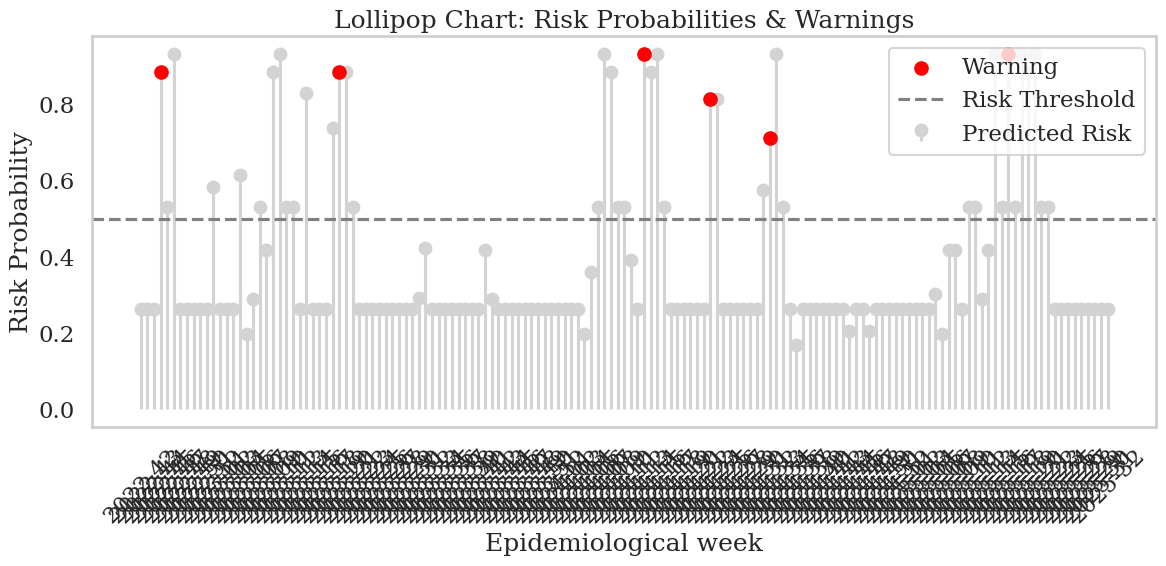

In [99]:
plt.figure(figsize=(12, 6))
plt.stem(set_muni['year_week'], set_muni['risk_probs'],
         basefmt=" ", linefmt='lightgray', markerfmt='o', label='Predicted Risk')

plt.scatter(set_muni.loc[set_muni['warning_final_mem_surge_01'] == 1, 'year_week'],
            set_muni.loc[set_muni['warning_final_mem_surge_01'] == 1, 'risk_probs'],
            color='red', label='Warning', zorder=3)

plt.axhline(0.5, color='gray', linestyle='--', label='Risk Threshold')
plt.xticks(rotation=45)
plt.title('Lollipop Chart: Risk Probabilities & Warnings')
plt.xlabel('Epidemiological week')
plt.ylabel('Risk Probability')
plt.legend()
plt.tight_layout()
plt.grid(False)
plt.show()


In [100]:
set_muni = set_muni.assign(LR = (set_muni["risk_probs"] > 0.5).astype(int))


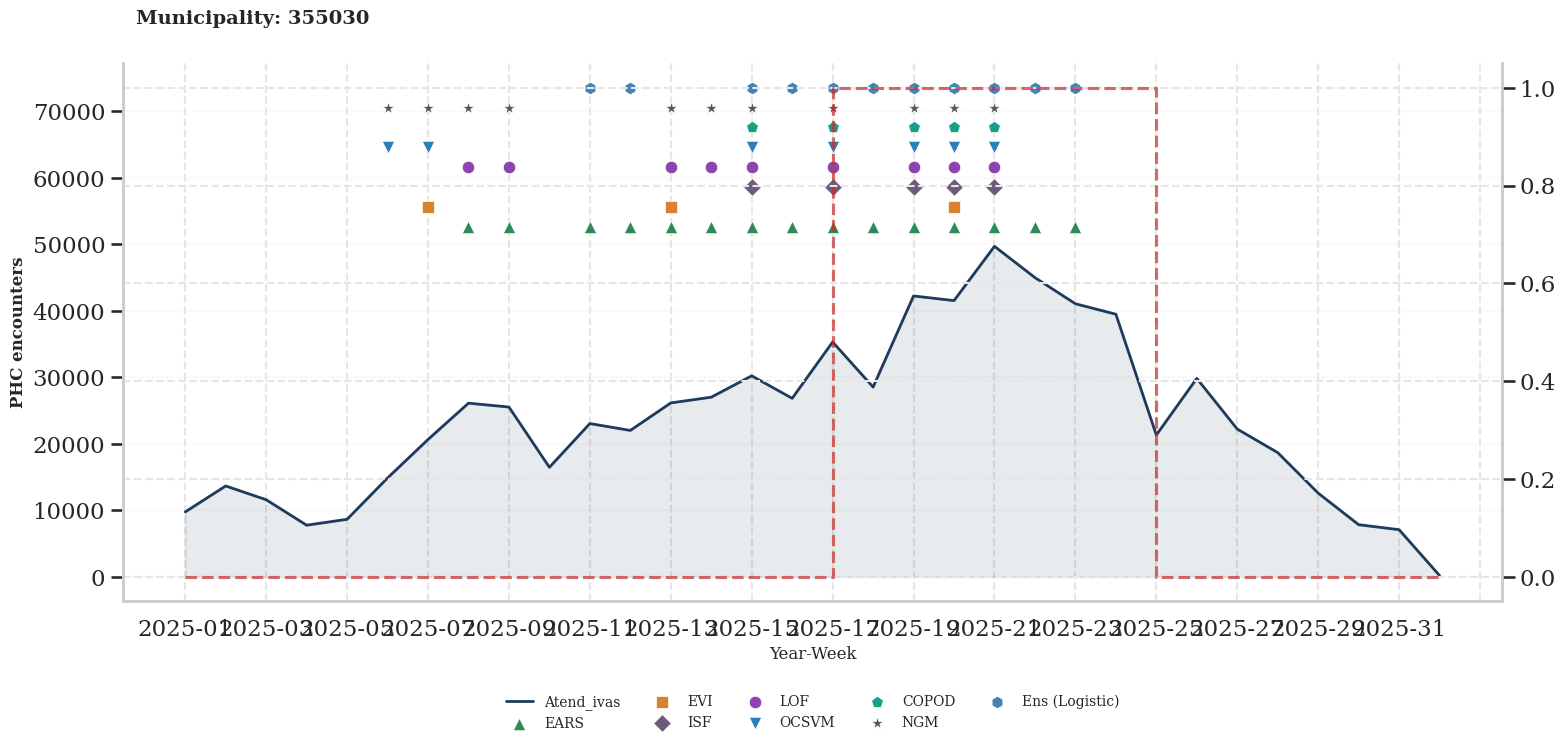

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style context
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

muni = code

dta_plot = set_muni[set_muni.year_week >= '2025-01'].copy()#dta_plot.co_ibge.unique()[0]

fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Color Palette (Lancet-inspired) ---
# 1. Expanded Lancet Color Palette
colors = {
    "main": "#1f3b5c",       # Deep navy (Trend line)
    "secondary": "#c52e2e",  # Muted crimson (MEM surges)
    "ears": "#2e8b57",       # Sea green
    "evi": "#d9822b",        # Ochre/Amber
    #"vot": "#555555",        # Slate grey (Voting)
    "LR": "#4682B4",         # Steel blue (Logistic)
    # New distinct colors for the EWS models:
    "isf": "#6c5b7b",        # Muted purple
    "lof": "#8e44ad",        # Amethyst
    "ocsvm": "#2980b9",      # Belize blue
    "copod": "#16a085",       # Nephrite green
    'rt': "#555555"         # Slate grey (Rt)
}


# 1. Primary Plot: Atend_ivas
ax1.plot(dta_plot["year_week"], dta_plot["atend_ivas"], 
         color=colors["main"], linewidth=2, label="Atend_ivas", zorder=2)
ax1.fill_between(dta_plot["year_week"], dta_plot["atend_ivas"], 
                 color=colors["main"], alpha=0.1)

# 2. Binary Signal Strip (Warnings)
# Instead of scaling by max(), we create a logical offset
y_max = dta_plot["atend_ivas"].max()
offset = y_max * 0.06

# Grouped scatter plots for signals
signals = [
    ("sinal_ears_atend",   colors["ears"],  "^", "EARS"),
    ("sinal_evi_ivas",     colors["evi"],   "s", "EVI"),
    ("EWS_ISF",            colors["isf"],   "D", "ISF"),
    ("EWS_LOF",            colors["lof"],   "o", "LOF"),
    ("EWS_OCSVM",          colors["ocsvm"], "v", "OCSVM"),
    ("EWS_COPOD",          colors["copod"], "p", "COPOD"),
    ('EWS_Rt',              colors["rt"],   "*", "NGM"),
    ("LR",                 colors["LR"],    "h", "Ens (Logistic)")
]

for i, (col, color, marker, lbl) in enumerate(signals):
    mask = dta_plot[col] == 1
    ax1.scatter(dta_plot.loc[mask, "year_week"], 
                [y_max + (i+1)*offset] * mask.sum(), 
                marker=marker, color=color, s=80, label=lbl, 
                edgecolors='white', linewidth=0.5, zorder=4)

# 4. Secondary Axis & GRID
ax2 = ax1.twinx()
ax2.step(dta_plot["year_week"], dta_plot["mem_surge_01_correct_with_consec"], 
         where='post', color=colors["secondary"], linestyle="--", alpha=0.7)

# 4. Axes Aesthetics
ax1.set_ylabel("PHC encounters", fontweight='bold', fontsize=12)
ax1.set_xlabel("Year-Week", fontsize=12)

# Remove top/right spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Grid - only horizontal for readability
ax1.yaxis.grid(True, linestyle='-', alpha=0.2)
ax1.xaxis.set_major_locator(plt.MaxNLocator(20)) # Automatically reduces clutter

# 5. Legend and Labeling
ax1.text(0.01, 1.1, f"Municipality: {muni}", transform=ax1.transAxes, 
         fontsize=14, fontweight='bold', va='top')

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc="upper center", bbox_to_anchor=(0.5, -0.15), 
           ncol=5, frameon=False, fontsize=10)


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# all with lag

In [102]:
# Split dataset
X = set_muni[all_features].fillna(0) 

y = set_muni['mem_surge_01_correct_with_consec']#'warning_final_mem_surge_01']#'mem_surge_01_corect_with_consec']#

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500,stratify=y)

# Fit model
clf = LogisticRegression(class_weight="balanced",max_iter=500) #fit_intercept=False
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.83      0.89        24
           1       0.56      0.83      0.67         6

    accuracy                           0.83        30
   macro avg       0.75      0.83      0.78        30
weighted avg       0.87      0.83      0.84        30



In [103]:
set_muni = set_muni.assign(risk_probs = clf.predict_proba(X)[:, 1])

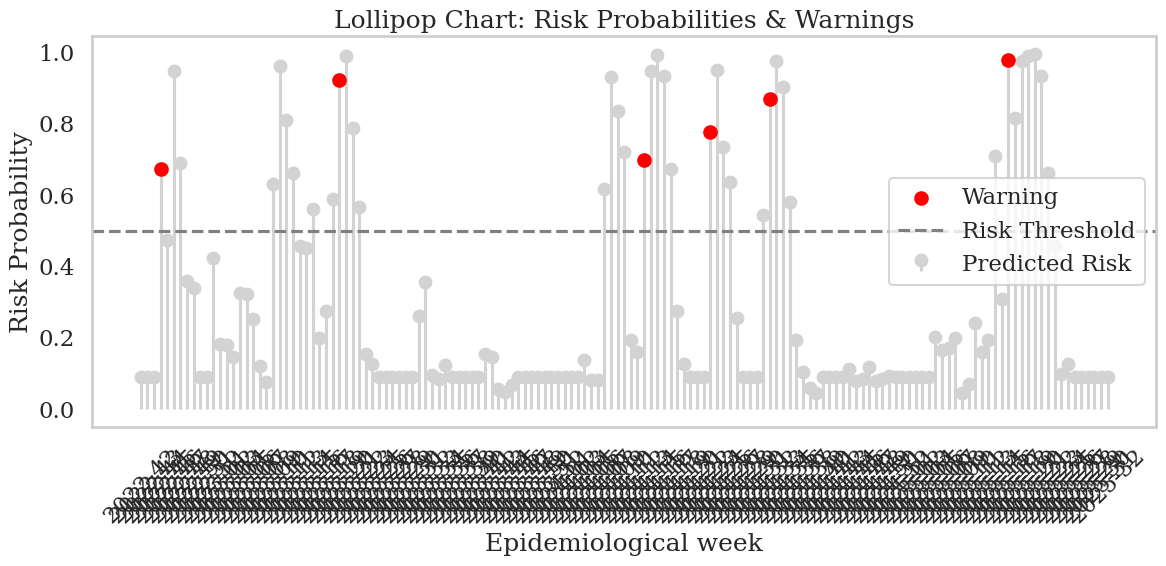

In [104]:
plt.figure(figsize=(12, 6))
plt.stem(set_muni['year_week'], set_muni['risk_probs'],
         basefmt=" ", linefmt='lightgray', markerfmt='o', label='Predicted Risk')

plt.scatter(set_muni.loc[set_muni['warning_final_mem_surge_01'] == 1, 'year_week'],
            set_muni.loc[set_muni['warning_final_mem_surge_01'] == 1, 'risk_probs'],
            color='red', label='Warning', zorder=3)

plt.axhline(0.5, color='gray', linestyle='--', label='Risk Threshold')
plt.xticks(rotation=45)
plt.title('Lollipop Chart: Risk Probabilities & Warnings')
plt.xlabel('Epidemiological week')
plt.ylabel('Risk Probability')
plt.legend()
plt.tight_layout()
plt.grid(False)
plt.show()


In [105]:
set_muni = set_muni.assign(LR = (set_muni["risk_probs"] > 0.5).astype(int))


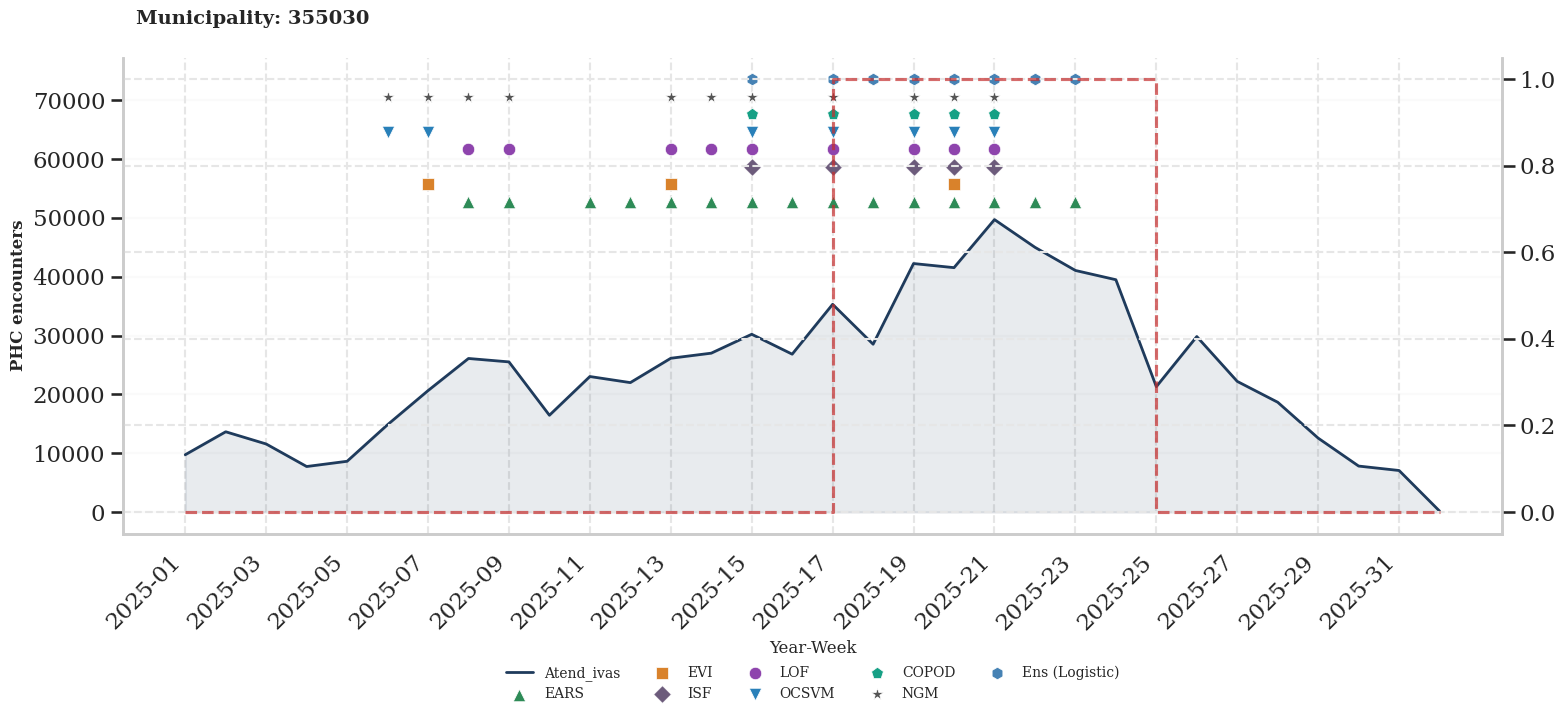

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style context
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

muni = code

dta_plot = set_muni[set_muni.year_week >= '2025-01'].copy()#dta_plot.co_ibge.unique()[0]

fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Color Palette (Lancet-inspired) ---
# 1. Expanded Lancet Color Palette
colors = {
    "main": "#1f3b5c",       # Deep navy (Trend line)
    "secondary": "#c52e2e",  # Muted crimson (MEM surges)
    "ears": "#2e8b57",       # Sea green
    "evi": "#d9822b",        # Ochre/Amber
    #"vot": "#555555",        # Slate grey (Voting)
    "LR": "#4682B4",         # Steel blue (Logistic)
    # New distinct colors for the EWS models:
    "isf": "#6c5b7b",        # Muted purple
    "lof": "#8e44ad",        # Amethyst
    "ocsvm": "#2980b9",      # Belize blue
    "copod": "#16a085",       # Nephrite green
    'rt': "#555555"         # Slate grey (Rt)
}


# 1. Primary Plot: Atend_ivas
ax1.plot(dta_plot["year_week"], dta_plot["atend_ivas"], 
         color=colors["main"], linewidth=2, label="Atend_ivas", zorder=2)
ax1.fill_between(dta_plot["year_week"], dta_plot["atend_ivas"], 
                 color=colors["main"], alpha=0.1)

# 2. Binary Signal Strip (Warnings)
# Instead of scaling by max(), we create a logical offset
y_max = dta_plot["atend_ivas"].max()
offset = y_max * 0.06

# Grouped scatter plots for signals
signals = [
    ("sinal_ears_atend",   colors["ears"],  "^", "EARS"),
    ("sinal_evi_ivas",     colors["evi"],   "s", "EVI"),
    ("EWS_ISF",            colors["isf"],   "D", "ISF"),
    ("EWS_LOF",            colors["lof"],   "o", "LOF"),
    ("EWS_OCSVM",          colors["ocsvm"], "v", "OCSVM"),
    ("EWS_COPOD",          colors["copod"], "p", "COPOD"),
    ('EWS_Rt',              colors["rt"],   "*", "NGM"),
    ("LR",                 colors["LR"],    "h", "Ens (Logistic)")
]

for i, (col, color, marker, lbl) in enumerate(signals):
    mask = dta_plot[col] == 1
    ax1.scatter(dta_plot.loc[mask, "year_week"], 
                [y_max + (i+1)*offset] * mask.sum(), 
                marker=marker, color=color, s=80, label=lbl, 
                edgecolors='white', linewidth=0.5, zorder=4)

# 4. Secondary Axis & GRID
ax2 = ax1.twinx()
ax2.step(dta_plot["year_week"], dta_plot["mem_surge_01_correct_with_consec"], 
         where='post', color=colors["secondary"], linestyle="--", alpha=0.7)

# 4. Axes Aesthetics
ax1.set_ylabel("PHC encounters", fontweight='bold', fontsize=12)
ax1.set_xlabel("Year-Week", fontsize=12)

# Remove top/right spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Grid - only horizontal for readability
ax1.yaxis.grid(True, linestyle='-', alpha=0.2)
ax1.xaxis.set_major_locator(plt.MaxNLocator(20)) # Automatically reduces clutter

# 5. Legend and Labeling
ax1.text(0.01, 1.1, f"Municipality: {muni}", transform=ax1.transAxes, 
         fontsize=14, fontweight='bold', va='top')

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc="upper center", bbox_to_anchor=(0.5, -0.25), 
           ncol=5, frameon=False, fontsize=10)

# --- Reduce x-axis clutter ---
ax1.set_xticks(plotdf["year_week"][::2])
ax1.set_xticklabels(plotdf["year_week"][::2], rotation=45, ha="right")
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()